Proyecto 2: Introducción a la Inteligencia Artificial

Integrantes: Vicente Arechavala, Johan Riveros

Profesor: Gabriel Cabas

### Librerias a utilizar

In [ ]:
#Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os
import platform
import torch
import torch.nn as nn

In [ ]:
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

### Carga de modelo de preentreno

Se decidió utilizar resnet18, dado que es una red con suficiente capacidad de aprendizaje para la detección de las diferencias entre los 3 diferentes estilos de manos provenientes del dataset. Además, dada las limitaciones actuales de las computadoras de quienes realizan el trabajo, la utilización de un modelo más exigente (como el visto en clases, resnet50) implica mayores costos computacionales, lo cual no necesariamente garantiza mejores resultados. 

In [4]:
#Se usará resnet18 (por ahora por limitaciones de cpu)
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

### Transformaciones definidas para resnet18

Las imagenes serán transformadas en un formato compatible para ResNet18. Son redimensionadas y cortadas en 244x244 píxeles, el cual es el tamaño habitual de entrada para dicho modelo preentrenado.

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

### Carga del dataset

Se cargan las distintas carpetas presentes del dataset. El dataset es un trabajo en donde se exponen distintas posiciones de manos (distintivas del grupo piedra, papel y tijeras) por medio de fotos tomadas por un grupo de personas hacia ellos mismos. Las fotografías están previamente divididas en los formatos necesarios para la aplicación de un modelo de predicción, es decir, train, val y test, por lo que no fue necesaria una modificación en este apartado.

In [ ]:
NUM_WORKERS = 0 if platform.system() == "Windows" else min(4, os.cpu_count() or 0)
print("NUM_WORKERS:", NUM_WORKERS)

train_folder = ImageFolder("C:/Users/Vicen/OneDrive/Documentos/Intro IA/Proyecto 2 - Introducción a la IA/archive/train", transform=train_transform)
val_folder = ImageFolder("C:/Users/Vicen/OneDrive/Documentos/Intro IA/Proyecto 2 - Introducción a la IA/archive/val", transform=eval_transform)
test_folder = ImageFolder("C:/Users/Vicen/OneDrive/Documentos/Intro IA/Proyecto 2 - Introducción a la IA/archive/test", transform=eval_transform)

train_loader = DataLoader(train_folder, batch_size=64, shuffle=True,
                           num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(val_folder, batch_size=64, shuffle=False,
                         num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)
test_loader = DataLoader(test_folder, batch_size=64, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)

CLASSES = train_folder.classes
NUM_CLASSES = len(CLASSES)

print("Clases:", train_folder.class_to_idx)
print(f"Train: {len(train_folder)} | Val: {len(val_folder)} | Test: {len(test_folder)}")


NUM_WORKERS: 0
Clases: {'paper': 0, 'rock': 1, 'scissors': 2}
Train: 1020 | Val: 804 | Test: 540


Se observa una cantidad importante de imágenes en la carpeta "val" y "test". A pesar de que la cantidad de imágenes en la carpeta "train" es mayor, normalmente debería seguir una distribución de sobre el 70% de las imágenes, cosa que no se cumple en este caso, ello pudiendo generar problemas para el modelo preentrenado para predecir correctamente las formas de las palmas de las manos. Aun así, se ha decidido no cambiar la distribución original prevista por el dataset, pues de esta manera se podrá evaluar de manera integra los resultados obtenidos, de forma que se pueda evaluar de si llega a existir esta problemática o no con las configuraciones actuales del dataset. 

### Distribución de las clases del dataset

Imágenes por clase (train):
paper       362
rock        329
scissors    329
Name: count, dtype: int64


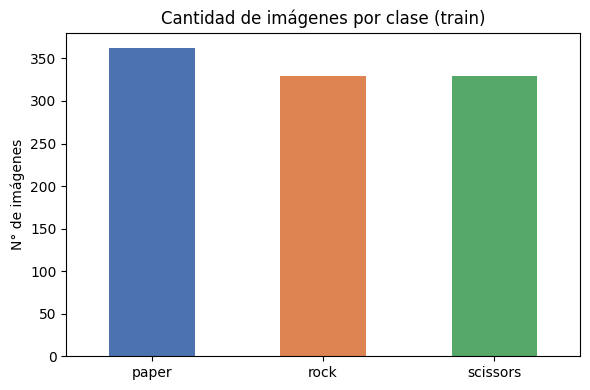


Desbalance (max/min): 1.10x


In [7]:
# Distribución de clases en el set de entrenamiento
train_labels = [label for _, label in train_folder.samples]
class_counts = pd.Series(train_labels).value_counts().sort_index()
class_counts.index = [CLASSES[i] for i in class_counts.index]

print("Imágenes por clase (train):")
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Cantidad de imágenes por clase (train)")
plt.ylabel("N° de imágenes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nDesbalance (max/min): {class_counts.max() / class_counts.min():.2f}x")


Se observa que existe una distribución ligeramente mayor para las imágenes que contienen "papel" respecto de las otras opciones, que tienen una distribución exactamente igual. Esto, sin embargo, no necesariamente representa una problemática, pues representa un desbalance bajo, por lo que no se aplicarán técnicas de reducción de dicho desbalance.

### Imagenes aleatorias del dataset

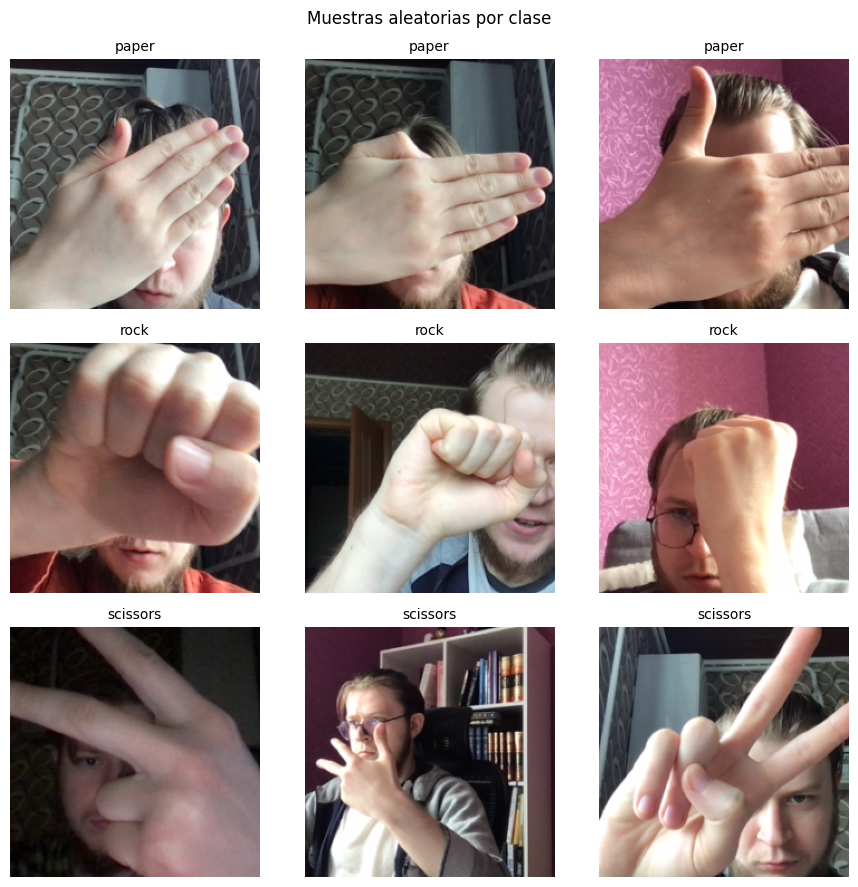

In [ ]:
# Muestra visual: 3 imágenes por clase (antes de normalizar)
raw_view = ImageFolder("C:/Users/Vicen/OneDrive/Documentos/Intro IA/Proyecto 2 - Introducción a la IA/archive/train", transform=transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224)
]))

fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, 3 * len(CLASSES)))
rng = np.random.default_rng(42)

for row, class_name in enumerate(CLASSES):
    class_idx = raw_view.class_to_idx[class_name]
    sample_indices = [i for i, (_, lbl) in enumerate(raw_view.samples) if lbl == class_idx]
    chosen = rng.choice(sample_indices, size=3, replace=False)
    for col, idx in enumerate(chosen):
        img, _ = raw_view[idx]
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(class_name, fontsize=10)
        ax.axis("off")

plt.suptitle("Muestras aleatorias por clase")
plt.tight_layout()
plt.show()


Se observan las distintas imágenes que existen para las 3 opciones que tiene el dataset. Como se puede ver en la figura, las imágenes del dataset no cuentan con una estructura específica, es decir, más allá de las 3 opciones permitidas, los diseños mostrados en cámara no siguen un patrón específico de distancia o posición, lo que da mayor diversidad en los patrones que debe determinar el dataset como pertenecientes a cierto tipo de características que deriven en la opción correcta o incorrecta (determinar correctamente si se trata de una piedra, papel, o tijera).

### Verififcación de tamaños

In [1]:
sample_paths = [raw_view.samples[i][0] for i in rng.choice(len(raw_view), size=min(200, len(raw_view)), replace=False)]
sizes = [Image.open(p).size for p in sample_paths]
widths, heights = zip(*sizes)

print(f"Ancho: min={min(widths)}, max={max(widths)}, promedio={np.mean(widths):.0f}")
print(f"Alto:  min={min(heights)}, max={max(heights)}, promedio={np.mean(heights):.0f}")

NameError: name 'rng' is not defined

Todas las fotografías son de 300x300 píxeles. Esto significa que todo los conjuntos son de un tamaño estandarizado, y por ende, la reducción previamente descrita (224x224) no debería ser perjudicial para ninguna de las carpetas u opciones del dataset.

### Modelo

### Congelar backbone

Los parámetros originales de ResNet18 se congelan para conservar las características visuales aprendidas previamente en ImageNet. De esta forma, no se reajustan millones de parámetros con un dataset relativamente pequeño, lo que reduce el costo computacional y el riesgo de overfitting.

In [10]:
for param in model.parameters():
    param.requires_grad = False

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
model.to(device)

Device: cpu


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### Nueva cabeza de clasificación

Se reemplaza la capa final original proveniente de ResNet18 por una nueva adaptada al problema, es decir, la elección de piedra, papel o tijera. 
Se incorpora BatchNorm1d para estabilizar la distribución de activaciones durante los entrenamientos. ReLu como función no lineal y Dropout como regularización. 

In [ ]:
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Parámetros entrenables: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.2f}%)")

Parámetros entrenables: 132,611 / 11,309,123 (1.17%)


Al ser solo 1.17% de los parámetros realmente entrenados, quiere decir que se ha aplicado la transferencia de aprendizaje con el backbone congelado.

### Optimizador

Se aplica CrossEntropyLoss, pues dicha función es adecuada para este tipo de problemas, es decir, para un problema multiclase donde las imágenes pertenecen a una única categoría. Además, se aplica el optimizador AdamW por la capacidad de adaptar el tamaño de los parámetros durante el entrenamiento. Por último se utiliza weight_decay, equivalente a regresión ridge, de forma de evitar el posible sobreajuste de los datos. 

También se utiliza ReduceLROnPlateau para disminuir el learning rate cuando la pérdida de validación deja de mejorar. Como también se aplica early stopping, que monitorea la pérdida de validación y detiene el entrenamiento si no existen mejoras durante un número definido de épocas. 

Ambos son aplicados de modo de evitar la sobreexigencia computacional.

In [ ]:
criterion = CrossEntropyLoss()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

EPOCHS = 20
PATIENCE = 5

In [14]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_no_improve = 0

In [15]:
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} acc={train_acc:.3f} "
          f"| val_loss={val_loss:.4f} acc={val_acc:.3f}")

    # --- early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping en epoch {epoch+1}")
            break

model.load_state_dict(best_state)

Epoch 1/20 | train_loss=1.1171 acc=0.401 | val_loss=1.0444 acc=0.465
Epoch 2/20 | train_loss=0.9429 acc=0.551 | val_loss=0.9655 acc=0.516
Epoch 3/20 | train_loss=0.8258 acc=0.660 | val_loss=0.8862 acc=0.595
Epoch 4/20 | train_loss=0.7515 acc=0.725 | val_loss=0.8321 acc=0.652
Epoch 5/20 | train_loss=0.7059 acc=0.745 | val_loss=0.7833 acc=0.708
Epoch 6/20 | train_loss=0.6243 acc=0.797 | val_loss=0.7591 acc=0.729
Epoch 7/20 | train_loss=0.6075 acc=0.791 | val_loss=0.7378 acc=0.734
Epoch 8/20 | train_loss=0.5464 acc=0.823 | val_loss=0.7105 acc=0.749
Epoch 9/20 | train_loss=0.5309 acc=0.823 | val_loss=0.6838 acc=0.755
Epoch 10/20 | train_loss=0.4948 acc=0.845 | val_loss=0.6753 acc=0.750
Epoch 11/20 | train_loss=0.4679 acc=0.862 | val_loss=0.6648 acc=0.744
Epoch 12/20 | train_loss=0.4678 acc=0.850 | val_loss=0.6571 acc=0.749
Epoch 13/20 | train_loss=0.4599 acc=0.844 | val_loss=0.6549 acc=0.740
Epoch 14/20 | train_loss=0.4237 acc=0.870 | val_loss=0.6565 acc=0.746
Epoch 15/20 | train_loss=0.42

<All keys matched successfully>

Durante los Epoch, se observa que la pérdida de entrenamiento fue constante (pasó de 1.1171 a 0.3609), al igual que la pérdida de validación (1.0444 a 0.5792). Al mismo tiempo el accuracy de entrenamiento aumentó de 0.401 a 0.888, de la misma forma ocurre con el accuracy de validación, que aumentó de 0.465 a 0.785.
Estos resultados determinan que el modelo "aprendió" patrones que le resultan útiles para la clasificación de las imágenes, y dicho aprendizaje se estaba trasladando al conjunto de validación. No se activó el early stopping en ninguna de las iteraciones, porque el modelo seguía mejorando.

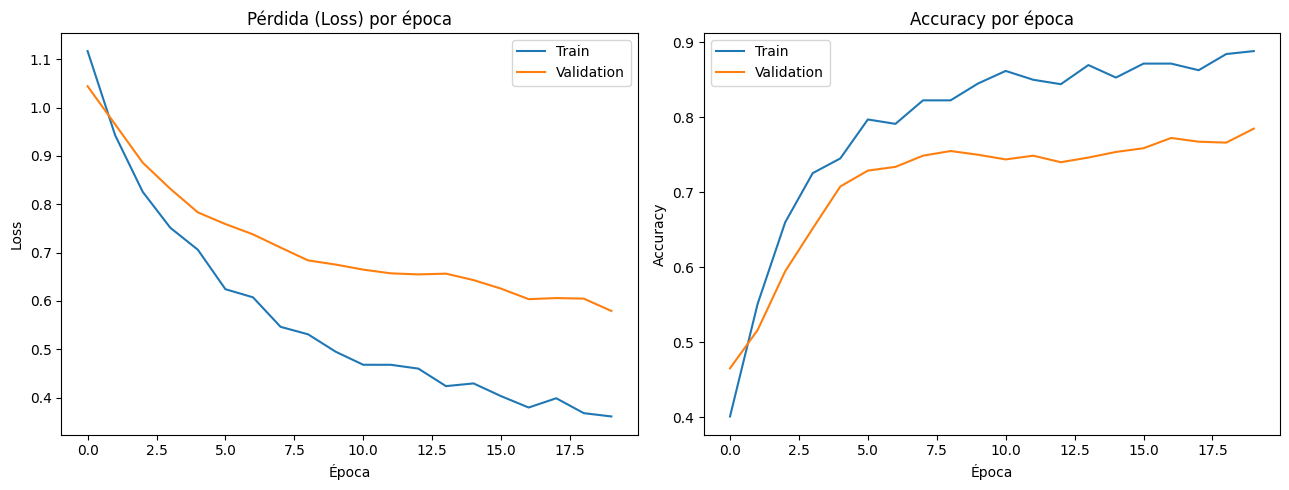

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Pérdida (Loss) por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].set_title("Accuracy por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


Tal como se observó anteriormente, las pérdidas de entrenamiento y validación, así como las mejoras en el accuracy de los mismos tienen cierta consistencia. Dadas las leves mejoras en el crecimiento del accuracy para la validación desde el Epoch 10 en adelante (mayormente observable con los valores obtenidos en el ejercicio anterior) vemos que es posible que el modelo esté experimentando de overfitting. Sin embargo, las iteraciones realizadas aún conservan una diferencia entre entrenamiento y validación (diferencia entre 0.888 y 0.785), por lo que se puede argumentar que es un overfitting leve o controlado. Es menester que en caso de realizar mayor cantidad de iteraciones se observe dicha diferencia, porque es posible que en más de 20 iteraciones si se presente un caso de overfitting mayor al que se muestra actualmente.

En vista lo anterior, se considera que el modelo es apto para el siguiente paso de testeo.

### Testeo

In [17]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy en test: {test_acc:.4f}")

print("\nReporte de clasificación:")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=3, zero_division=0))


Accuracy en test: 0.6056

Reporte de clasificación:
              precision    recall  f1-score   support

       paper      0.486     0.580     0.528       176
        rock      0.737     0.463     0.569       188
    scissors      0.651     0.784     0.711       176

    accuracy                          0.606       540
   macro avg      0.625     0.609     0.603       540
weighted avg      0.627     0.606     0.602       540



Se observa un accuracy del 0.6056 para el test, y si bien podría considerarse un valor relativamente bajo, pues el accuracy obtenido en la validación fue de 0.785, esto puede ocurrir dada la posibilidad de que las imágenes de la carpeta "test" contengan carácterísticas ligeramente distintas de las otras carpetas. A pesar de lo dicho, el valor obtenido en al accuracy del test determina que el modelo aprendió patrones relevantes que le permiten identificar con cierta claridad las opciones posibles.

La clase con mayor desempeño es sin duda la de las tijeras, pues si bien tiene una presición de 0.651, cuenta con un recall de 0.784, y un f1-score de 0.711, por lo que el modelo identifica correctamente la mayoría de las imágenes con tijeras.
La clase con mayor presición fue la piedra, pero a costa de un recall de 0.463 (el más bajo de las 3 opciones), y un f1-score de 0.569. Esto significa que el sistema falla muy pocas veces cuando detecta una piedra, pero que más de la mitad de las veces no detecta piedra cuando realmente lo es.
Los valores obtenidos en papel son bastante malos, pues con una presición de 0.486, recall de 0.580 y f1-score de 0.528, se determina que el modelo tiene complicaciones para distinguir cuando se trata de esta categoría.

Matriz de confusión

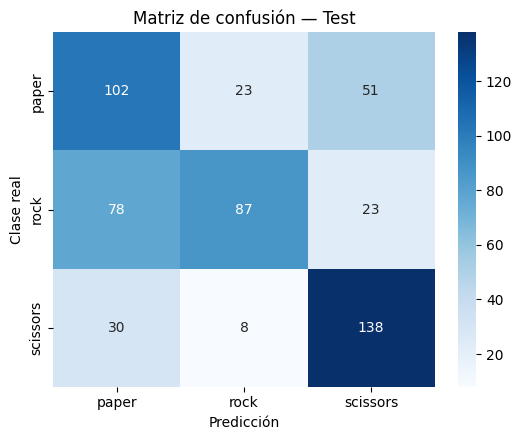

In [18]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Matriz de confusión — Test")
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()


La matriz de confusión obtenida muestra lo que se argumentó previamente. 

La clase mayormente reconocida fue la de las tijeras, y fue pocas veces confundida con piedra, aunque si 30 veces confundida con papel.

La clase piedra, tal como se indicó previamente cuenta con un recall de 0.463, lo que se puede observar en los resultados cuando la clase real era piedra, que solamente se determinó correctamente en 87 de todos los casos. De hecho, muchas veces el sistema confundió la clase piedra con papel, pues ocurrió en 78 casos.

Por último, en la clase papel se acertó en 102 de todos los casos, en donde el principal error fue que el sistema atribuyó 51 de los casos como tijeras. Este error puede haber ocurrido dada una posición de manos que tuviese patrones mas atribuibles a las características que el sistema determina como tijeras. 

Visualización de aciertos

In [2]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

model.eval()
images, labels = next(iter(test_loader))
images_dev = images.to(device)
with torch.no_grad():
    preds = model(images_dev).argmax(1).cpu()

n_show = min(9, len(images))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, img, true_label, pred_label in zip(axes.flat, images[:n_show], labels[:n_show], preds[:n_show]):
    ax.imshow(denormalize(img))
    true_name, pred_name = CLASSES[true_label], CLASSES[pred_label]
    correct = true_label == pred_label
    ax.set_title(f"Real: {true_name} | Pred: {pred_name}",
                 color="green" if correct else "red", fontsize=10)
    ax.axis("off")
for ax in axes.flat[n_show:]:
    ax.axis("off")

plt.suptitle("Ejemplos de predicciones en test (verde = correcto, rojo = error)")
plt.tight_layout()
plt.show()


NameError: name 'model' is not defined

Como se observa en las imágenes, el modelo parece tener dificultades al detectar cuando se trata de un papel si es que las manos de las imágenes procesadas están en cierta posición. Es decir, cuando la palma de la persona está más abierta el sistema logra detectar correctamente papel, sin embargo, cuando la palma está más de lado, el sistema parece tener dificultades para entender dicha característica, y por tanto, confunde con la posición de manos que más se le asemeja, siendo esta las tijeras. 